In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [3]:
df=pd.read_csv("college_placement_data.csv")
df

,StudentID,Year,Branch,Gender,CGPA,Backlogs,Internships,Projects,Certifications,AptitudeScore,CommunicationSkill,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,Salary_INR,CompanyName,JobCity
0,1,2023,ECE,Male,8.29,0,1,4,1,68,Excellent,Yes,97,93,Placed,810781.0,HCL,Bangalore
1,2,2021,BioTech,Male,6.31,0,0,2,2,59,Average,Yes,79,56,Not Placed,NaN,NaN,NaN
2,3,2021,EE,Male,6.92,0,0,3,2,53,Poor,Yes,90,55,Placed,628230.0,Capgemini,Chennai
3,4,2024,ME,Male,6.71,0,1,1,2,71,Poor,Yes,70,61,Not Placed,NaN,NaN,NaN
4,5,2023,CSE,Male,7.43,1,1,2,1,99,Good,No,72,74,Placed,867680.0,Tech Mahindra,Pune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,2023,CE,Female,7.44,0,0,2,0,98,Poor,No,57,58,Not Placed,NaN,NaN,NaN
1496,1497,2022,ME,Male,8.21,0,3,3,1,71,Excellent,Yes,76,97,Placed,955072.0,Mindtree,Pune
1497,1498,2023,ECE,Male,7.70,0,0,2,2,68,Good,No,89,81,Placed,716535.0,Hexaware,Delhi
1498,1499,2023,ECE,Male,6.69,2,2,1,4,46,Average,Yes,75,59,Placed,766004.0,L&T Infotech,Gurugram


In [4]:
df["PlacementStatus"].value_counts()

PlacementStatus
Placed        1208
Not Placed     292
Name: count, dtype: int64

In [80]:
px.histogram(df,x="PlacementStatus",color="PlacementStatus")

In [7]:
branched_placed=df[df["PlacementStatus"]=="Placed"].groupby("Branch").size()
branched_placed

Branch
BioTech     70
CE         124
CSE        408
ECE        206
EE         114
IT         157
ME         129
dtype: int64

In [8]:
branch_total=df.groupby("Branch").size()

In [9]:
branch_rate=(branched_placed/branch_total*100).round(2).reset_index()
branch_rate.columns = ['Branch', 'PlacementRate']
print(branch_rate)

    Branch  PlacementRate
0  BioTech          72.92
1       CE          77.50
2      CSE          87.55
3      ECE          74.91
4       EE          77.55
5       IT          87.71
6       ME          72.88


In [10]:
branch_rate_df = branch_rate.sort_values('PlacementRate', ascending=False)
print(branch_rate_df)

    Branch  PlacementRate
5       IT          87.71
2      CSE          87.55
4       EE          77.55
1       CE          77.50
3      ECE          74.91
0  BioTech          72.92
6       ME          72.88


In [11]:
px.bar(branch_rate_df,x="Branch",y="PlacementRate",title='Placement Rate by Branch (%)',
             color='PlacementRate',
             color_continuous_scale='Greens',
             text='PlacementRate')

In [12]:
gender_placement=df.groupby(['Gender',"PlacementStatus"]).size().reset_index()
gender_placement.columns=["Gender","PlacementStatus","Count"]
gender_placement
px.bar(gender_placement,x="Gender",y="Count",color="PlacementStatus",barmode='group',
title="Gender-wise Placement", color_continuous_scale="Blue")


<Axes: xlabel='Gender', ylabel='Count'>

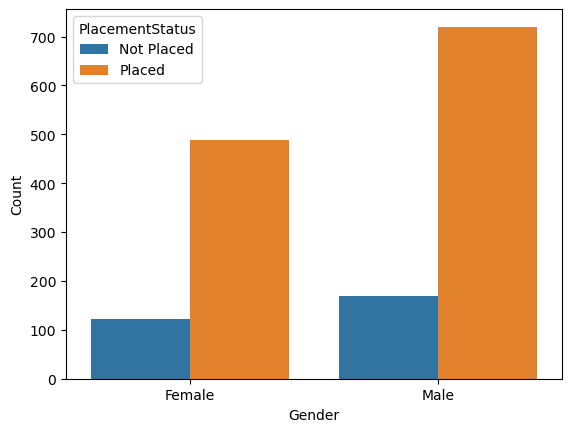

In [13]:
sns.barplot(data=gender_placement,x="Gender",y="Count",hue="PlacementStatus")

In [14]:
cgpa_wise=df.groupby("PlacementStatus")["CGPA"].mean().reset_index()
cgpa_wise.columns=["PlacementStatus","CGPA"]
cgpa_wise

,PlacementStatus,CGPA
0,Not Placed,7.175959
1,Placed,7.588526


In [15]:
px.box(df,x="PlacementStatus",y="CGPA",color="PlacementStatus",title='CGPA Distribution — Placed vs Not Placed')

In [16]:
placed_student=df[df['PlacementStatus'] == 'Placed'].groupby("Internships").size()
total_student=df.groupby("Internships").size()
print(placed_student)
print(total_student)
placementRate_intern=(placed_student/total_student *100).round(2).reset_index()
placementRate_intern.columns=["Internships","PlacementRate"]
print(placementRate_intern)


Internships
0    347
1    536
2    226
3     99
dtype: int64
Internships
0    464
1    655
2    270
3    111
dtype: int64
   Internships  PlacementRate
0            0          74.78
1            1          81.83
2            2          83.70
3            3          89.19


In [17]:
px.bar(placementRate_intern,x="Internships",y="PlacementRate",title="Placement Rate of Intern Student",color="PlacementRate")

In [18]:
Backlog_placed=df.groupby(["PlacementStatus","Backlogs"]).size().reset_index()
Backlog_placed.columns=["placementStatus","Backlogs","Counts"]
print(Backlog_placed)

  placementStatus  Backlogs  Counts
0      Not Placed         0     142
1      Not Placed         1      72
2      Not Placed         2      61
3      Not Placed         3      17
4          Placed         0     796
5          Placed         1     289
6          Placed         2      86
7          Placed         3      37


In [19]:
fig=px.bar(Backlog_placed,x="Backlogs",y="Counts",
color="placementStatus",barmode="group",title='Backlogs vs Placement')
fig.show()

In [ ]:
#Cell 18
backlog_place=df[df["PlacementStatus"]=="Placed"].groupby("Backlogs").size()
total_backlog=df.groupby("Backlogs").size()
backlog_rate=(backlog_place/total_backlog *100).round(2).reset_index()
backlog_rate.columns=["Backlogs","PlacementRate"]


In [21]:
px.bar(backlog_rate,x="Backlogs",y="PlacementRate",title="Backlogs % of Placed Student",color='PlacementRate',text="PlacementRate", color_continuous_scale='Reds_r')

In [23]:
Placed_train=df[df["PlacementStatus"]=="Placed"].groupby("PlacementTraining").size() 
total_train=df.groupby("PlacementTraining").size()

print(Placed_train)
print(total_train)
train_rate=(Placed_train/total_train *100).round(2).reset_index()
train_rate.columns=["Placement_Training","training_Rate"]

PlacementTraining
No     401
Yes    807
dtype: int64
PlacementTraining
No     511
Yes    989
dtype: int64


In [24]:
px.bar(train_rate,x="Placement_Training",y="training_Rate",color="training_Rate",text="training_Rate",
title="Placement Training Placed Rate")

In [46]:
Salary_Branch_Avg=df.groupby("Branch")["Salary_INR"].mean().round(2).reset_index()
Salary_Branch_Avg.columns=["Branch","Salary_INR"]

In [47]:
px.bar(Salary_Branch_Avg,x="Branch",y="Salary_INR",color="Salary_INR")

In [59]:
df.groupby("Branch")["Salary_INR"].max().reset_index()

,Branch,Salary_INR
0,BioTech,919889.0
1,CE,975341.0
2,CSE,1052020.0
3,ECE,990675.0
4,EE,952258.0
5,IT,1009546.0
6,ME,975560.0


In [7]:
df.groupby("Branch")["Salary_INR"].mean().idxmax()

'CSE'

In [54]:
total_company_hire=df.dropna(subset=["CompanyName"])

In [55]:
total_company_hire=total_company_hire["CompanyName"].value_counts().reset_index()
total_company_hire.columns=["CompanyName","StudentNo"]
print(total_company_hire)

      CompanyName  StudentNo
0           Wipro         93
1        Flipkart         80
2             Ola         79
3       Cognizant         75
4    L&T Infotech         75
5   Tech Mahindra         72
6         Mphasis         69
7          Amazon         68
8        Hexaware         68
9         Infosys         68
10            HCL         67
11          Paytm         67
12       Mindtree         64
13      Capgemini         58
14      Accenture         58
15         Zomato         53
16            TCS         49
17            IBM         45


In [56]:
px.bar(total_company_hire,x="CompanyName",y="StudentNo",text="StudentNo",color="StudentNo",title="No of Student Hired by Companies")

<Axes: xlabel='CompanyName', ylabel='StudentNo'>

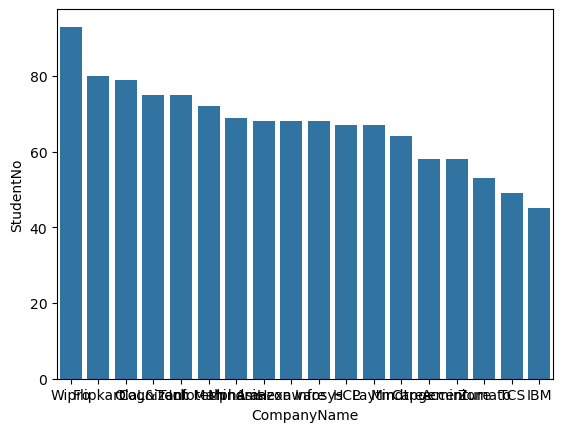

In [17]:
sns.barplot(data=total_company_hire,x="CompanyName",y="StudentNo")

<BarContainer object of 18 artists>

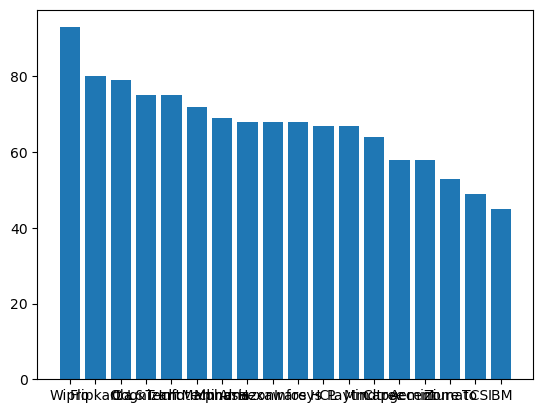

In [20]:
plt.bar(total_company_hire["CompanyName"], total_company_hire["StudentNo"])

In [21]:
df

,StudentID,Year,Branch,Gender,CGPA,Backlogs,Internships,Projects,Certifications,AptitudeScore,CommunicationSkill,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,Salary_INR,CompanyName,JobCity
0,1,2023,ECE,Male,8.29,0,1,4,1,68,Excellent,Yes,97,93,Placed,810781.0,HCL,Bangalore
1,2,2021,BioTech,Male,6.31,0,0,2,2,59,Average,Yes,79,56,Not Placed,NaN,NaN,NaN
2,3,2021,EE,Male,6.92,0,0,3,2,53,Poor,Yes,90,55,Placed,628230.0,Capgemini,Chennai
3,4,2024,ME,Male,6.71,0,1,1,2,71,Poor,Yes,70,61,Not Placed,NaN,NaN,NaN
4,5,2023,CSE,Male,7.43,1,1,2,1,99,Good,No,72,74,Placed,867680.0,Tech Mahindra,Pune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,2023,CE,Female,7.44,0,0,2,0,98,Poor,No,57,58,Not Placed,NaN,NaN,NaN
1496,1497,2022,ME,Male,8.21,0,3,3,1,71,Excellent,Yes,76,97,Placed,955072.0,Mindtree,Pune
1497,1498,2023,ECE,Male,7.70,0,0,2,2,68,Good,No,89,81,Placed,716535.0,Hexaware,Delhi
1498,1499,2023,ECE,Male,6.69,2,2,1,4,46,Average,Yes,75,59,Placed,766004.0,L&T Infotech,Gurugram


In [44]:
avg_city_salary=df.dropna(subset=["Salary_INR"])
avg_city_salary=avg_city_salary.groupby("JobCity")["Salary_INR"].mean().round(2).reset_index()
avg_city_salary.columns=["JobCity","Salary_INR"]
print(avg_city_salary)

     JobCity  Salary_INR
0  Bangalore   764561.28
1    Chennai   765750.93
2      Delhi   772133.94
3   Gurugram   781079.92
4  Hyderabad   772875.24
5     Mumbai   775286.37
6      Noida   769174.70
7       Pune   774766.44


In [132]:
px.bar(avg_city_salary,x="JobCity",y="Salary_INR",color="Salary_INR",title="Average salaries in Cities")

In [57]:
Placed_Cgpa=df[df["PlacementStatus"]=="Placed"]

fig=px.scatter(Placed_Cgpa,x="CGPA",y="Salary_INR",color="Salary_INR",title="CGPA vs Salary — Placed Students")
fig.show()

In [60]:
df

,StudentID,Year,Branch,Gender,CGPA,Backlogs,Internships,Projects,Certifications,AptitudeScore,CommunicationSkill,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,Salary_INR,CompanyName,JobCity
0,1,2023,ECE,Male,8.29,0,1,4,1,68,Excellent,Yes,97,93,Placed,810781.0,HCL,Bangalore
1,2,2021,BioTech,Male,6.31,0,0,2,2,59,Average,Yes,79,56,Not Placed,NaN,NaN,NaN
2,3,2021,EE,Male,6.92,0,0,3,2,53,Poor,Yes,90,55,Placed,628230.0,Capgemini,Chennai
3,4,2024,ME,Male,6.71,0,1,1,2,71,Poor,Yes,70,61,Not Placed,NaN,NaN,NaN
4,5,2023,CSE,Male,7.43,1,1,2,1,99,Good,No,72,74,Placed,867680.0,Tech Mahindra,Pune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,2023,CE,Female,7.44,0,0,2,0,98,Poor,No,57,58,Not Placed,NaN,NaN,NaN
1496,1497,2022,ME,Male,8.21,0,3,3,1,71,Excellent,Yes,76,97,Placed,955072.0,Mindtree,Pune
1497,1498,2023,ECE,Male,7.70,0,0,2,2,68,Good,No,89,81,Placed,716535.0,Hexaware,Delhi
1498,1499,2023,ECE,Male,6.69,2,2,1,4,46,Average,Yes,75,59,Placed,766004.0,L&T Infotech,Gurugram


In [77]:
Salary_Com=df[df["PlacementStatus"]=="Placed"].dropna(subset=["Salary_INR"])
Salary_Com
px.box(Salary_Com,x="CommunicationSkill",y="Salary_INR",color="CommunicationSkill",title="Communication Skill vs Salary",category_orders={"CommunicationSkill":["Poor","Average","Good","Excellent"]})

In [103]:
df["CGPA_Group"]=pd.cut(df["CGPA"],bins=[5.0,7.5,8.5,10],labels=["Low","Medium","High"])
print(df["CGPA_Group"].value_counts())

df=df.dropna(subset=["CGPA_Group"])
print(df["CGPA_Group"].isna().sum())

CGPA_Group
Low       736
Medium    612
High      150
Name: count, dtype: int64
0


In [122]:
placed=df[df["PlacementStatus"]=="Placed"].groupby(["CGPA_Group","Internships"]).size()
total_std=df.groupby(["CGPA_Group","Internships"]).size()
print(placed)
print(total_std)



CGPA_Group  Internships
Low         0              152
            1              226
            2              111
            3               55
Medium      0              152
            1              248
            2               90
            3               29
High        0               43
            1               61
            2               25
            3               15
dtype: int64
CGPA_Group  Internships
Low         0              223
            1              315
            2              136
            3               62
Medium      0              197
            1              274
            2              107
            3               34
High        0               44
            1               64
            2               27
            3               15
dtype: int64


C:\Users\Satyam\AppData\Local\Temp\ipykernel_18676\3067469907.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Satyam\AppData\Local\Temp\ipykernel_18676\3067469907.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [124]:
CGPA_Inter_Realtion=(placed/total_std*100).round(2).reset_index()
CGPA_Inter_Realtion.columns=["Cgpa_Group","Internships","placeRate"]
print(CGPA_Inter_Realtion)

   Cgpa_Group  Internships  placeRate
0         Low            0      68.16
1         Low            1      71.75
2         Low            2      81.62
3         Low            3      88.71
4      Medium            0      77.16
5      Medium            1      90.51
6      Medium            2      84.11
7      Medium            3      85.29
8        High            0      97.73
9        High            1      95.31
10       High            2      92.59
11       High            3     100.00


In [134]:
px.bar(CGPA_Inter_Realtion,x="Cgpa_Group",color="Internships",y="placeRate",barmode="group",category_orders={"Cgpa_Group": ["Low","Medium","High"]},title="CGPA + Internships VS PlacementRate")